# Pandas Part 4: Clustering and Cluster Dynamics

This notebook rebuilds the enriched feature set required for clustering, then covers KMeans, UMAP/PCA views, and the follow-up cluster-specific consequence analysis.

Links:
- [Pandas index](../data_analytics_project_pandas.ipynb)
- [Shared helpers](../functions.py)

In [43]:
%load_ext autoreload
%autoreload 2
# TODO: Update it to the same level as the polars notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    for candidate in [start] + list(start.parents):
        if (candidate / 'data' / 'co2_data.csv').exists() and (candidate / 'notebooks' / 'functions.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root from the current working directory.')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
NOTEBOOKS_DIR = REPO_ROOT / 'notebooks'
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
DATA_DIR = REPO_ROOT / 'data'

In [45]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
import umap.umap_ as umap

import timeit
import requests

from functions import (
    apply_correlation_to_df,
    normalize_column,
    z_score_column,
    safe_divide,
    classify_income_group,
    get_top_bottom_n,
    compute_energy_mix_shares,
    plot_dual_axis_timeseries,
    run_kmeans_elbow,
    flatten_owid_panel_json,
    prepare_source_trend_table,
    compute_group_concentration,
)

# professional theme: clean white grid with muted palette
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.titlesize": 16,
})
%matplotlib inline

## CO2 Emissions Data

We load the Our World in Data CO2 dataset, which contains 79 columns spanning energy mix, land use, and emissions breakdowns. For this analysis we reduce it to five key variables: `country`, `year`, `iso_code`, `population`, and `co2` (total production-based CO2 emissions in millions of tonnes).

Two important filtering steps:
- **Drop rows without `iso_code`**: The dataset includes aggregate entities like "Africa", "OECD", and "World" that lack ISO country codes. Removing these ensures we work exclusively with individual nation-states.
- **Filter to post-1960**: GDP data from the World Bank only begins in 1960, so we align the time range to enable a clean merge later.

In [46]:
co2_df = pd.read_csv(DATA_DIR / 'co2_data.csv')

# choose what columns to keep (can be changed, but this is the most important)
selected_columns = ['country', 'year', 'iso_code', 'population', 'co2']

# drop the columns that are not in the selected_columns list
co2_df = co2_df[selected_columns].copy()

# remove entries with no iso code(Continents and other groups)
co2_df = co2_df[co2_df['iso_code'].notna() & (co2_df['iso_code'].str.strip() != '')]
co2_df = co2_df[co2_df['year'] > 1960]

co2_df


,country,year,iso_code,population,co2
211,Afghanistan,1961,AFG,9214082.0,0.491
212,Afghanistan,1962,AFG,9404410.0,0.689
213,Afghanistan,1963,AFG,9604491.0,0.707
214,Afghanistan,1964,AFG,9814317.0,0.839
215,Afghanistan,1965,AFG,10036003.0,1.007
...,...,...,...,...,...
50406,Zimbabwe,2020,ZWE,15526887.0,8.491
50407,Zimbabwe,2021,ZWE,15797220.0,10.223
50408,Zimbabwe,2022,ZWE,16069061.0,12.232
50409,Zimbabwe,2023,ZWE,16340829.0,13.443


## GDP Data

The World Bank GDP dataset arrives in **wide format** - one column per year (1960, 1961, ..., 2024). This is convenient for spreadsheet viewing but incompatible with tidy-data principles needed for plotting and merging. We use `pd.melt()` to reshape it into long format with one row per country-year observation.

Key steps:
- **Melt** year columns into `year` (int) and `gdp` (numeric) columns
- **Rename** `Country Code` to `iso_code` to create a shared merge key with the CO2 dataset
- **Drop missing GDP values** - not all countries have GDP records for every year, particularly in earlier decades or for newly independent states

In [47]:
# load GDP data
gdp_df = pd.read_csv(DATA_DIR / 'gdp_data.csv')

# reshape from wide to long format
# melt the year columns into rows
year_columns = [col for col in gdp_df.columns if col.isdigit()]
gdp_df = gdp_df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    value_vars=year_columns,
    var_name='year',
    value_name='gdp'
)

# convert year to integer and gdp to numeric
gdp_df['year'] = gdp_df['year'].astype(int)
gdp_df['gdp'] = pd.to_numeric(gdp_df['gdp'], errors='coerce')

# rename Country Code to iso_code for merging
gdp_df = gdp_df.rename(columns={'Country Code': 'iso_code'})

# keep only the columns we need
gdp_df = gdp_df[['iso_code', 'year', 'gdp']]

# remove rows with missing GDP values
gdp_df = gdp_df.dropna(subset=['gdp'])

gdp_df

,iso_code,year,gdp
1,AFE,1960,2.420569e+10
3,AFW,1960,1.190481e+10
9,ARG,1960,1.586547e+10
13,AUS,1960,1.863568e+10
14,AUT,1960,6.624086e+09
...,...,...,...
17284,WSM,2024,1.175750e+09
17285,XKX,2024,1.119725e+10
17287,ZAF,2024,4.011450e+11
17288,ZMB,2024,2.530319e+10


## Merging the Datasets

We perform a **left join** of GDP onto the CO2 dataframe using `iso_code` and `year` as composite keys. A left join preserves every CO2 record and attaches GDP where available - countries or years without World Bank GDP data simply receive NaN. This is preferable to an inner join because it avoids silently discarding emission records that are still valuable for other analyses.
### Missing Data Heatmap

Before proceeding, we visualize data completeness. The heatmap below shows each variable as a column and each record as a row, with bright cells indicating missing values. This diagnostic is important because it reveals whether missingness is **random** or **systematic** - for instance, GDP data may be consistently absent for certain countries or time periods, which would bias any analysis that silently drops incomplete rows.

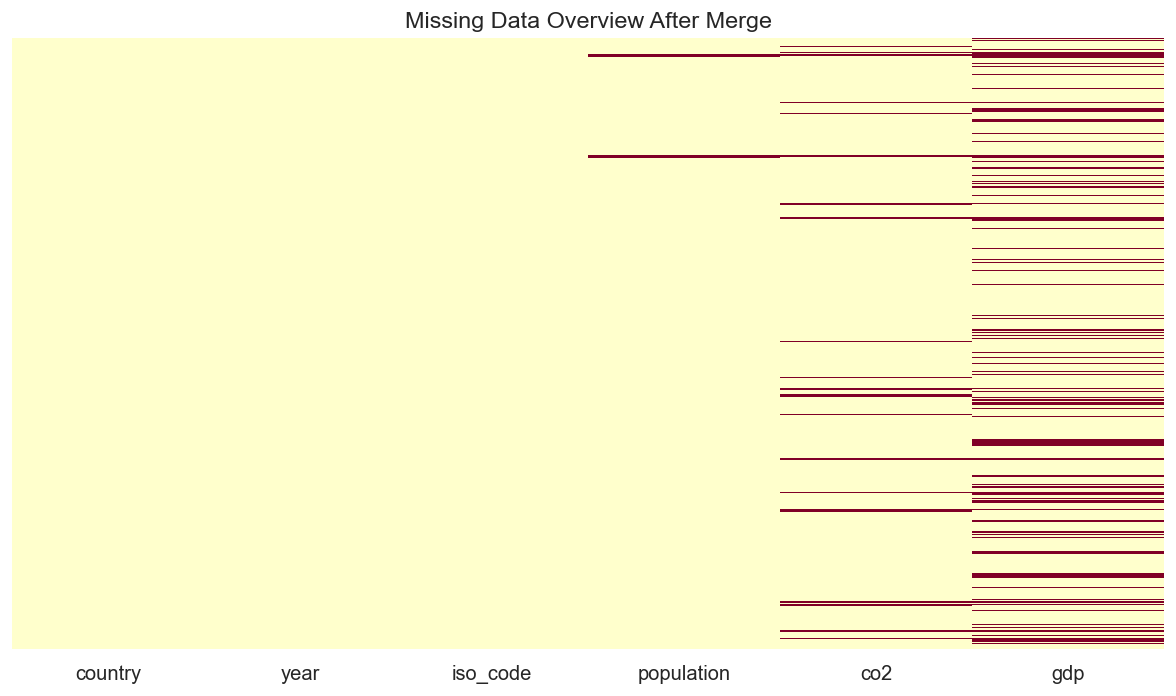

In [48]:
# merge the datasets on iso_code and year
base_df = co2_df.merge(
    gdp_df,
    on=['iso_code', 'year'],
    how='left',
    suffixes=('_co2', '_gdp')
)

# missing data heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(base_df.isnull(), yticklabels=False, cbar=False, cmap='YlOrRd', ax=ax)
ax.set_title("Missing Data Overview After Merge")
plt.tight_layout()
plt.show()


### Data Quality Summary

The GDP column shows the most missingness - this is expected since many countries (especially newly independent or conflict-affected states) lack World Bank GDP records in earlier decades. Importantly, the missingness is **systematic** rather than random: it concentrates in specific countries and time periods. This means any analysis involving GDP will implicitly exclude these observations, so conclusions are most robust for the subset of countries with consistent economic data.

## Per-Capita Metrics

Absolute CO2 and GDP figures are dominated by population size - China and India will always top the charts simply because they have the most people, not necessarily because their economies or industries are more carbon-intensive on a per-person basis. Dividing by population yields **per-capita** values that enable fairer cross-country comparisons: how much does the average citizen emit, and how wealthy is the average citizen?

- **CO2 per capita** is expressed in **tonnes per person** (the raw CO2 column is in millions of tonnes, so we multiply by 10⁶ before dividing by population).
- **GDP per capita** is in **current USD per person**.

We use `np.divide` with a `where` guard to handle zero or missing population entries without raising division errors.

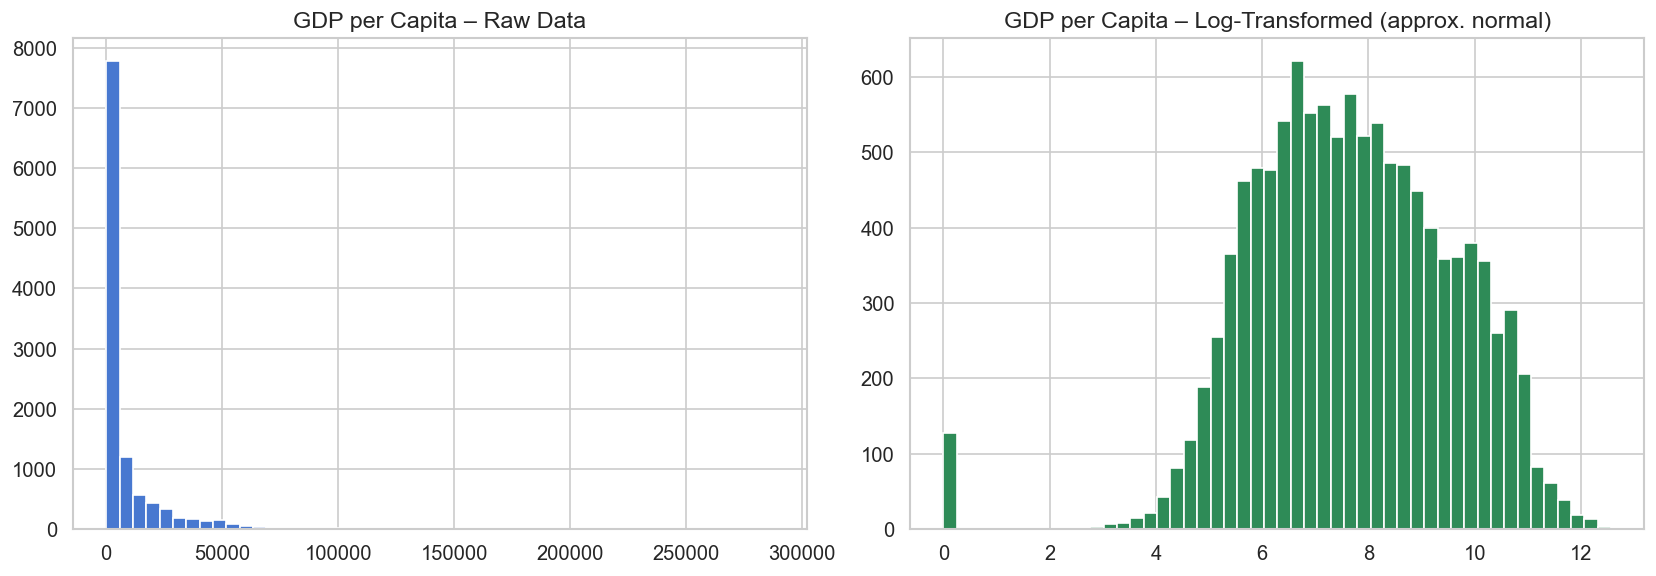

In [49]:
# CO2 is in millions of tonnes; multiply by 1e6 to get tonnes, then divide by population
base_df['co2_per_capita'] = safe_divide(base_df['co2'].values * 1e6, base_df['population'].values)
base_df['gdp_per_capita'] = safe_divide(base_df['gdp'].values, base_df['population'].values)

# Log-transform per-capita metrics for better visualization
base_df['log_gdp_pc'] = np.log1p(base_df['gdp_per_capita'].values)
base_df['log_co2_pc'] = np.log1p(base_df['co2_per_capita'].values)

# compare raw and log-transformed data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(base_df['gdp_per_capita'].dropna(), bins=50, edgecolor='white')
axes[0].set_title('GDP per Capita – Raw Data')
axes[1].hist(base_df['log_gdp_pc'].dropna(), bins=50, edgecolor='white', color='seagreen')
axes[1].set_title('GDP per Capita – Log-Transformed (approx. normal)')
plt.tight_layout()
plt.show()


## Income Group Classification

To move beyond individual country case studies, we classify each observation by **income group** using the World Bank's Gross National Income (GNI) thresholds:

| Group | GNI per capita (current USD) |
|---|---|
| Low | $\leq$ 1,145 |
| Lower-Middle | 1,146 – 4,515 |
| Upper-Middle | 4,516 – 14,005 |
| High | $>$ 14,005 |

Source: [World Bank Country Classification (FY2025)](https://datahelpdesk.worldbank.org/knowledgebase/articles/906519-world-bank-country-and-lending-groups)

This allows us to ask a structural question: do emission trajectories differ systematically between rich and poor countries? We scrape current GNI per capita figures from Wikipedia and merge them onto our dataset, then apply `pd.cut` to assign income brackets based on GDP per capita as a proxy.

In [50]:
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_GNI_(nominal)_per_capita'

tables = pd.read_html(url, storage_options={'User-Agent': 'Mozilla/5.0'})

# table 1 contains the GNI per capita data
gni_df = tables[1]

dict = {
    'GNI per capita (US$)[1][3]': 'gni_per_capita'
}

gni_df = gni_df.rename(columns=dict)

gni_df



,Unnamed: 0,Country,gni_per_capita,Year
0,NaN,High Income Economies,NaN,2024
1,–,Bermuda (UK),145150.0,2024
2,1,Liechtenstein,116600.0,2009
3,2,Norway,98170.0,2024
4,3,Switzerland,95220.0,2024
...,...,...,...,...
207,187,Madagascar,510.0,2024
208,188,Yemen,470.0,2024
209,189,Afghanistan,370.0,2023
210,190,South Sudan,350.0,2024


In [51]:
# normalize 
gni_df['country_clean'] = normalize_column('Country', gni_df)
base_df['country_clean'] = normalize_column('country', base_df)

# left merge
main_df = pd.merge(base_df, gni_df[['country_clean', 'gni_per_capita']], 
                     on='country_clean', how='left')

# classify income groups using World Bank thresholds
main_df['income_group'] = classify_income_group(main_df['gni_per_capita'])

main_df

,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,country_clean,gni_per_capita,income_group
0,Afghanistan,1961,AFG,9214082.0,0.491,NaN,0.053288,NaN,NaN,0.051917,afghanistan,370.0,Low
1,Afghanistan,1962,AFG,9404410.0,0.689,NaN,0.073264,NaN,NaN,0.070704,afghanistan,370.0,Low
2,Afghanistan,1963,AFG,9604491.0,0.707,NaN,0.073611,NaN,NaN,0.071028,afghanistan,370.0,Low
3,Afghanistan,1964,AFG,9814317.0,0.839,NaN,0.085487,NaN,NaN,0.082029,afghanistan,370.0,Low
4,Afghanistan,1965,AFG,10036003.0,1.007,NaN,0.100339,NaN,NaN,0.095618,afghanistan,370.0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13947,Zimbabwe,2020,ZWE,15526887.0,8.491,3.198033e+10,0.546858,2059.674586,7.630789,0.436226,zimbabwe,2260.0,Lower-Middle
13948,Zimbabwe,2021,ZWE,15797220.0,10.223,4.128767e+10,0.647139,2613.603766,7.868868,0.499040,zimbabwe,2260.0,Lower-Middle
13949,Zimbabwe,2022,ZWE,16069061.0,12.232,4.075756e+10,0.761214,2536.399713,7.838895,0.566004,zimbabwe,2260.0,Lower-Middle
13950,Zimbabwe,2023,ZWE,16340829.0,13.443,3.587178e+10,0.822663,2195.223980,7.694495,0.600299,zimbabwe,2260.0,Lower-Middle


In [52]:
# Carbon intensity setup extracted from the original timing cell.
# carbon intensity: CO2 (millions of tonnes) per $1M GDP
gdp_in_millions = main_df['gdp'].values / 1_000_000
main_df['co2_per_gdp'] = safe_divide(main_df['co2'].values, gdp_in_millions)

# keep working from the enriched dataframe from here on
# this way later cells still have income groups and carbon intensity
base_df = main_df.copy()

In [53]:
# fetch electricity production data from Our World in Data
df_electricity = pd.read_csv(
    "https://ourworldindata.org/grapher/electricity-prod-source-stacked.csv?v=1&csvType=full&useColumnShortNames=true",
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)

# rename to concise column names
rename_map = {
    'code': 'iso_code',
    "other_renewables_excluding_bioenergy_generation__twh_chart_electricity_prod_source_stacked": "other_renewables",
    'bioenergy_generation__twh_chart_electricity_prod_source_stacked': 'bioenergy',
    'solar_generation__twh_chart_electricity_prod_source_stacked': 'solar',
    'wind_generation__twh_chart_electricity_prod_source_stacked': 'wind',
    'hydro_generation__twh_chart_electricity_prod_source_stacked': 'hydro',
    'nuclear_generation__twh_chart_electricity_prod_source_stacked': 'nuclear',
    'oil_generation__twh_chart_electricity_prod_source_stacked': 'oil',
    'gas_generation__twh_chart_electricity_prod_source_stacked': 'gas',
    'coal_generation__twh_chart_electricity_prod_source_stacked': 'coal',
}
df_electricity = df_electricity.rename(columns=rename_map)

# keep only individual countries (drop aggregates without ISO codes)
df_electricity = df_electricity[df_electricity['iso_code'].notna() & (df_electricity['iso_code'].str.strip() != '')]

print(f"Electricity data: {df_electricity.shape[0]:,} rows, "
      f"{df_electricity['iso_code'].nunique()} countries, "
      f"{df_electricity['year'].min()}-{df_electricity['year'].max()}")

df_electricity

Electricity data: 6,197 rows, 219 countries, 1985-2025


,entity,iso_code,year,other_renewables,bioenergy,solar,wind,hydro,nuclear,oil,gas,coal
26,Afghanistan,AFG,2000,0.0,0.00,0.00,0.0,0.31,0.0,0.17,0.0,0.00
27,Afghanistan,AFG,2001,0.0,0.00,0.00,0.0,0.50,0.0,0.15,0.0,0.04
28,Afghanistan,AFG,2002,0.0,0.00,0.00,0.0,0.56,0.0,0.11,0.0,0.04
29,Afghanistan,AFG,2003,0.0,0.00,0.00,0.0,0.63,0.0,0.19,0.0,0.09
30,Afghanistan,AFG,2004,0.0,0.00,0.00,0.0,0.56,0.0,0.17,0.0,0.06
...,...,...,...,...,...,...,...,...,...,...,...,...
6874,Zimbabwe,ZWE,2020,0.0,0.10,0.02,0.0,3.81,0.0,0.04,0.0,2.74
6875,Zimbabwe,ZWE,2021,0.0,0.11,0.02,0.0,5.93,0.0,0.00,0.0,2.51
6876,Zimbabwe,ZWE,2022,0.0,0.11,0.03,0.0,5.88,0.0,0.00,0.0,2.92
6877,Zimbabwe,ZWE,2023,0.0,0.12,0.03,0.0,5.46,0.0,0.00,0.0,4.38


In [54]:
green_cols = ['other_renewables', 'bioenergy', 'solar', 'wind', 'hydro', 'nuclear']
non_green_cols = ['coal', 'oil', 'gas']

df_electricity = compute_energy_mix_shares(df_electricity, green_cols, non_green_cols)

In [55]:
# start from the enriched dataframe, not the pre-income-group version
base_df = main_df.copy()

# columns coming from df_electricity (excluding merge keys and entity)
elec_cols = [c for c in df_electricity.columns if c not in ['entity', 'iso_code', 'year']]

# drop these from base_df if they already exist (handles notebook re-runs)
base_df = base_df.drop(columns=[c for c in elec_cols if c in base_df.columns])

# merge electricity data onto base_df
base_df = base_df.merge(
    df_electricity.drop(columns=['entity']),
    on=['iso_code', 'year'],
    how='inner'
)

base_df

,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,...,bioenergy,solar,wind,hydro,nuclear,oil,gas,coal,green_share,non_green_share
0,Afghanistan,2000,AFG,20130334.0,1.047,3.521418e+09,0.052011,174.930931,5.170091,0.050704,...,0.00,0.00,0.0,0.31,0.0,0.17,0.0,0.00,0.645833,0.354167
1,Afghanistan,2001,AFG,20284303.0,1.069,2.813572e+09,0.052701,138.706849,4.939546,0.051359,...,0.00,0.00,0.0,0.50,0.0,0.15,0.0,0.04,0.724638,0.275362
2,Afghanistan,2002,AFG,21378123.0,1.341,3.825701e+09,0.062728,178.954038,5.192701,0.060839,...,0.00,0.00,0.0,0.56,0.0,0.11,0.0,0.04,0.788732,0.211268
3,Afghanistan,2003,AFG,22733053.0,1.560,4.520947e+09,0.068623,198.871081,5.297673,0.066370,...,0.00,0.00,0.0,0.63,0.0,0.19,0.0,0.09,0.692308,0.307692
4,Afghanistan,2004,AFG,23560656.0,1.237,5.224897e+09,0.052503,221.763635,5.406111,0.051171,...,0.00,0.00,0.0,0.56,0.0,0.17,0.0,0.06,0.708861,0.291139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5554,Zimbabwe,2020,ZWE,15526887.0,8.491,3.198033e+10,0.546858,2059.674586,7.630789,0.436226,...,0.10,0.02,0.0,3.81,0.0,0.04,0.0,2.74,0.585693,0.414307
5555,Zimbabwe,2021,ZWE,15797220.0,10.223,4.128767e+10,0.647139,2613.603766,7.868868,0.499040,...,0.11,0.02,0.0,5.93,0.0,0.00,0.0,2.51,0.707118,0.292882
5556,Zimbabwe,2022,ZWE,16069061.0,12.232,4.075756e+10,0.761214,2536.399713,7.838895,0.566004,...,0.11,0.03,0.0,5.88,0.0,0.00,0.0,2.92,0.673378,0.326622
5557,Zimbabwe,2023,ZWE,16340829.0,13.443,3.587178e+10,0.822663,2195.223980,7.694495,0.600299,...,0.12,0.03,0.0,5.46,0.0,0.00,0.0,4.38,0.561562,0.438438


# Unsupervised Clustering: Country Archetypes

The analyses above used predefined income brackets to group countries. But do countries **naturally** cluster into distinct profiles when we let the data decide? We apply **KMeans clustering** on three features from the most recent year (2023):

1. **GDP per capita** - economic wealth
2. **CO2 per $1M GDP** - carbon intensity of the economy
3. **Non-green electricity share** - fossil fuel dependency in the power sector

All features are standardised (z-scored) before clustering to prevent GDP per capita (measured in thousands of USD) from dominating the distance metric over shares (measured between 0 and 1).

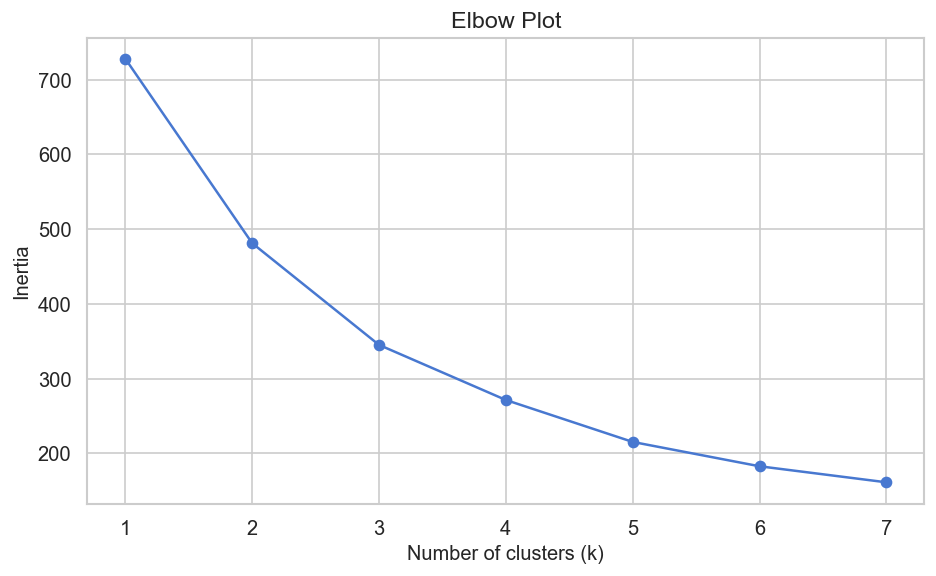

In [56]:
year = 2023

# use the enriched features from the previous prep steps
ml_features = ['log_gdp_pc','log_co2_pc', 'co2_per_gdp', 'non_green_share']

# fail early with a clearer message if a prep cell was skipped
missing_ml_features = [col for col in ml_features if col not in base_df.columns]
if missing_ml_features:
    raise KeyError(f"Missing clustering features: {missing_ml_features}. Re-run the carbon-intensity and electricity-merge cells above.")

# keep only the latest year and complete rows for clustering
cluster_df = base_df[base_df['year'] == year].dropna(subset=ml_features).copy()

# run kmeans elbow ( in numpy)
X = cluster_df[ml_features].to_numpy()

# run kmeans elbow
fig, ax = plt.subplots(figsize=(8, 5))
_, scaled_data, _, inertias, scaler = run_kmeans_elbow(
    X,
    k_range=range(1, 8),
    scale=True,
    random_state=42,
    n_init=10,
    n_clusters=None,
    plot=True,
    ax=ax,)
plt.tight_layout()

### Choosing the Number of Clusters

The elbow plot shows inertia (within-cluster sum of squares) for k = 1 through 7. The "elbow" at **k = 3** indicates diminishing returns beyond four clusters, making it the optimal choice for segmenting countries by economic and environmental characteristics.

In [57]:
# Cluster countries
cluster_labels, scaled_data, kmeans_model, inertias, scaler = run_kmeans_elbow(
    X,
    k_range=range(1, 8),
    n_clusters=3,
    plot=False,
    ax=None,
    scale=True,
    random_state=42,
    n_init=10,)

# Add cluster labels to the original data
cluster_df["cluster"] = cluster_labels

cluster_df

,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,...,solar,wind,hydro,nuclear,oil,gas,coal,green_share,non_green_share,cluster
23,Afghanistan,2023,AFG,41454762.0,10.516,1.715223e+10,0.253674,413.757885,6.027695,0.226079,...,0.09,0.00,0.75,0.0,0.10,0.00,0.03,0.865979,0.134021,0
48,Albania,2023,ALB,2811660.0,4.417,2.349124e+10,1.570958,8354.937200,9.030728,0.944279,...,0.30,0.00,8.71,0.0,0.00,0.00,0.00,1.000000,0.000000,0
73,Algeria,2023,DZA,46164222.0,202.847,2.479239e+11,4.394031,5370.476886,8.588858,1.685293,...,0.87,0.02,0.02,0.0,0.33,94.64,0.00,0.009491,0.990509,2
98,Angola,2023,AGO,36749909.0,21.675,1.071677e+11,0.589797,2916.136395,7.978358,0.463607,...,0.39,0.00,11.22,0.0,2.70,1.39,0.00,0.740317,0.259683,0
123,Antigua and Barbuda,2023,ATG,93331.0,0.641,2.005785e+09,6.868029,21491.092833,9.975440,2.062808,...,0.02,0.00,0.00,0.0,0.34,0.00,0.00,0.055556,0.944444,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5418,Vanuatu,2023,VUT,320422.0,0.188,1.115861e+09,0.586726,3482.473287,8.155785,0.461673,...,0.01,0.00,0.01,0.0,0.06,0.00,0.00,0.250000,0.750000,0
5442,Venezuela,2023,VEN,28300861.0,119.588,1.023765e+11,4.225596,3617.435051,8.193797,1.653569,...,0.01,0.02,64.98,0.0,3.26,3.69,0.00,0.903419,0.096581,2
5482,Vietnam,2023,VNM,100352189.0,347.399,4.338577e+11,3.461798,4323.350449,8.372017,1.495552,...,25.69,11.59,80.62,0.0,1.70,26.36,129.76,0.429408,0.570592,2
5532,Zambia,2023,ZMB,20723967.0,11.831,2.757796e+10,0.570885,1330.727677,7.194232,0.451639,...,0.15,0.00,17.09,0.0,0.01,0.00,2.13,0.890031,0.109969,0


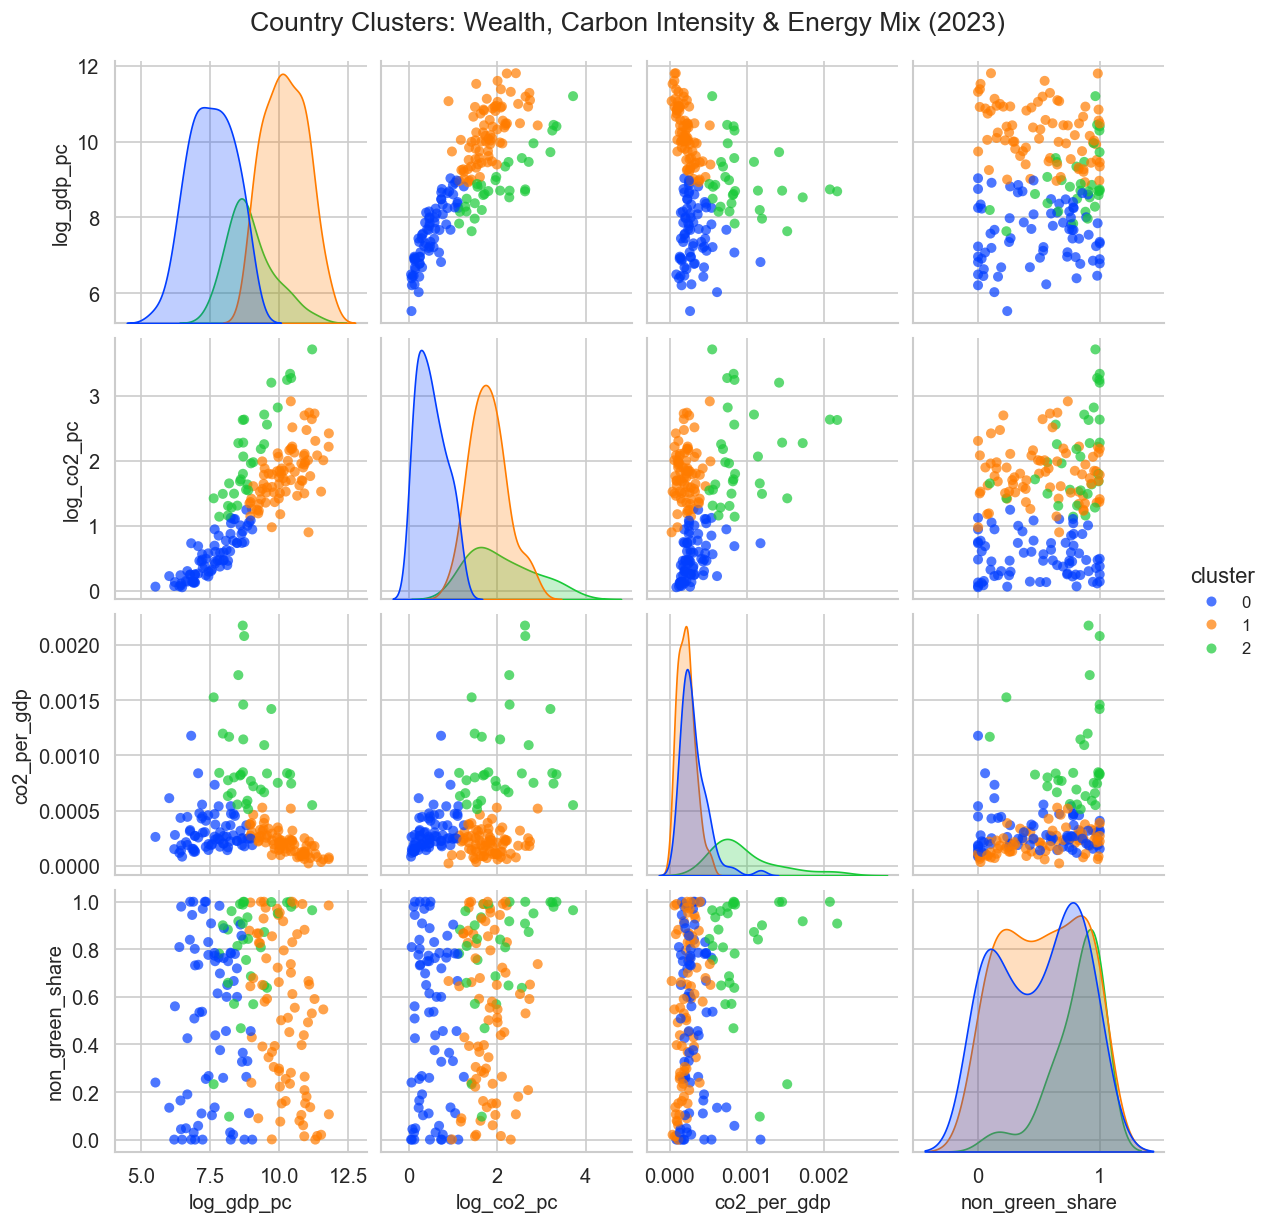

In [58]:
# create a pairplot of scatterplots
g = sns.pairplot(cluster_df, vars=ml_features, hue='cluster', palette='bright',
                 diag_kind='kde', plot_kws={'alpha': 0.7, 'edgecolor': 'none'})
                 
g.fig.suptitle(f'Country Clusters: Wealth, Carbon Intensity & Energy Mix ({year})', y=1.02)
plt.show()

### Interpreting the Pairplot

The pairplot visualizes pairwise relationships between the three clustering features - GDP per capita, CO2 per $M GDP, and non-green electricity share - with each point colored by its KMeans cluster assignment.

- **GDP per capita vs. CO2 per GDP** shows a clear inverse relationship: wealthier countries tend to emit far less CO2 per unit of economic output, reinforcing the efficiency narrative from earlier sections.
- **Non-green share vs. CO2 per GDP** correlates positively - countries that rely heavily on fossil fuels for electricity are also the least carbon-efficient economies overall.
- **GDP per capita vs. non-green share** is more dispersed, suggesting that wealth alone does not guarantee a clean electricity mix (e.g. oil-rich Gulf states are wealthy but fossil-dependent).

The KDE diagonals reveal that most clusters are well-separated along at least one axis, confirming that the three-cluster solution captures meaningful structural differences rather than arbitrary splits.

In [59]:
base_df

,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,...,bioenergy,solar,wind,hydro,nuclear,oil,gas,coal,green_share,non_green_share
0,Afghanistan,2000,AFG,20130334.0,1.047,3.521418e+09,0.052011,174.930931,5.170091,0.050704,...,0.00,0.00,0.0,0.31,0.0,0.17,0.0,0.00,0.645833,0.354167
1,Afghanistan,2001,AFG,20284303.0,1.069,2.813572e+09,0.052701,138.706849,4.939546,0.051359,...,0.00,0.00,0.0,0.50,0.0,0.15,0.0,0.04,0.724638,0.275362
2,Afghanistan,2002,AFG,21378123.0,1.341,3.825701e+09,0.062728,178.954038,5.192701,0.060839,...,0.00,0.00,0.0,0.56,0.0,0.11,0.0,0.04,0.788732,0.211268
3,Afghanistan,2003,AFG,22733053.0,1.560,4.520947e+09,0.068623,198.871081,5.297673,0.066370,...,0.00,0.00,0.0,0.63,0.0,0.19,0.0,0.09,0.692308,0.307692
4,Afghanistan,2004,AFG,23560656.0,1.237,5.224897e+09,0.052503,221.763635,5.406111,0.051171,...,0.00,0.00,0.0,0.56,0.0,0.17,0.0,0.06,0.708861,0.291139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5554,Zimbabwe,2020,ZWE,15526887.0,8.491,3.198033e+10,0.546858,2059.674586,7.630789,0.436226,...,0.10,0.02,0.0,3.81,0.0,0.04,0.0,2.74,0.585693,0.414307
5555,Zimbabwe,2021,ZWE,15797220.0,10.223,4.128767e+10,0.647139,2613.603766,7.868868,0.499040,...,0.11,0.02,0.0,5.93,0.0,0.00,0.0,2.51,0.707118,0.292882
5556,Zimbabwe,2022,ZWE,16069061.0,12.232,4.075756e+10,0.761214,2536.399713,7.838895,0.566004,...,0.11,0.03,0.0,5.88,0.0,0.00,0.0,2.92,0.673378,0.326622
5557,Zimbabwe,2023,ZWE,16340829.0,13.443,3.587178e+10,0.822663,2195.223980,7.694495,0.600299,...,0.12,0.03,0.0,5.46,0.0,0.00,0.0,4.38,0.561562,0.438438


# Further cluster analysis
Let's have a look at the clusters in detaiö, finding out what exactly is behind the clusters and how effective kmeans was

In [60]:
ml_features = ["log_gdp_pc", "log_co2_pc", "co2_per_gdp", "non_green_share", "cluster"]

# clean data
cluster_df.dropna()

# scale data
X = cluster_df[ml_features[0:4]].to_numpy()

X_scaled = StandardScaler().fit_transform(X)

# reduce dimensions
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42,)

# transform data
embedding = reducer.fit_transform(X_scaled)

cluster_df

/Users/fabianfrank/Documents/carbon_analysis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,...,solar,wind,hydro,nuclear,oil,gas,coal,green_share,non_green_share,cluster
23,Afghanistan,2023,AFG,41454762.0,10.516,1.715223e+10,0.253674,413.757885,6.027695,0.226079,...,0.09,0.00,0.75,0.0,0.10,0.00,0.03,0.865979,0.134021,0
48,Albania,2023,ALB,2811660.0,4.417,2.349124e+10,1.570958,8354.937200,9.030728,0.944279,...,0.30,0.00,8.71,0.0,0.00,0.00,0.00,1.000000,0.000000,0
73,Algeria,2023,DZA,46164222.0,202.847,2.479239e+11,4.394031,5370.476886,8.588858,1.685293,...,0.87,0.02,0.02,0.0,0.33,94.64,0.00,0.009491,0.990509,2
98,Angola,2023,AGO,36749909.0,21.675,1.071677e+11,0.589797,2916.136395,7.978358,0.463607,...,0.39,0.00,11.22,0.0,2.70,1.39,0.00,0.740317,0.259683,0
123,Antigua and Barbuda,2023,ATG,93331.0,0.641,2.005785e+09,6.868029,21491.092833,9.975440,2.062808,...,0.02,0.00,0.00,0.0,0.34,0.00,0.00,0.055556,0.944444,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5418,Vanuatu,2023,VUT,320422.0,0.188,1.115861e+09,0.586726,3482.473287,8.155785,0.461673,...,0.01,0.00,0.01,0.0,0.06,0.00,0.00,0.250000,0.750000,0
5442,Venezuela,2023,VEN,28300861.0,119.588,1.023765e+11,4.225596,3617.435051,8.193797,1.653569,...,0.01,0.02,64.98,0.0,3.26,3.69,0.00,0.903419,0.096581,2
5482,Vietnam,2023,VNM,100352189.0,347.399,4.338577e+11,3.461798,4323.350449,8.372017,1.495552,...,25.69,11.59,80.62,0.0,1.70,26.36,129.76,0.429408,0.570592,2
5532,Zambia,2023,ZMB,20723967.0,11.831,2.757796e+10,0.570885,1330.727677,7.194232,0.451639,...,0.15,0.00,17.09,0.0,0.01,0.00,2.13,0.890031,0.109969,0


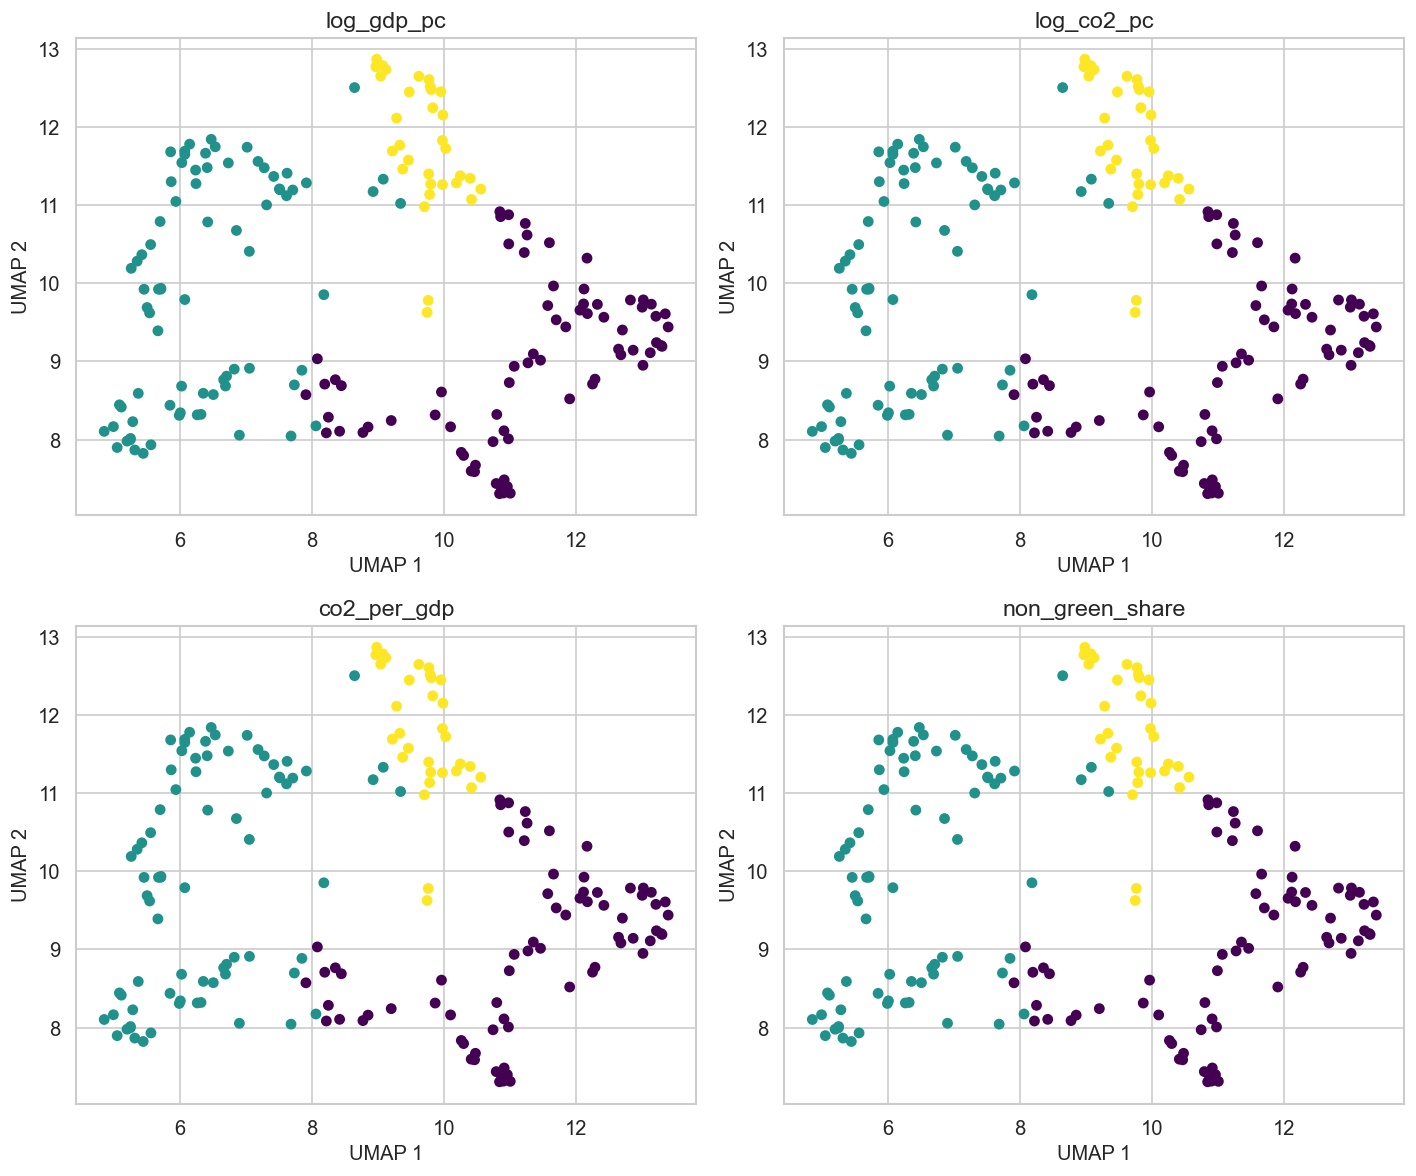

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# plot UMAP embeddings for each feature
for ax, feature in zip(axes.flatten(), ml_features):
    sc = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=cluster_df["cluster"],
        cmap="viridis",
        s=30)
    ax.set_title(feature)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    
plt.tight_layout()
plt.show()

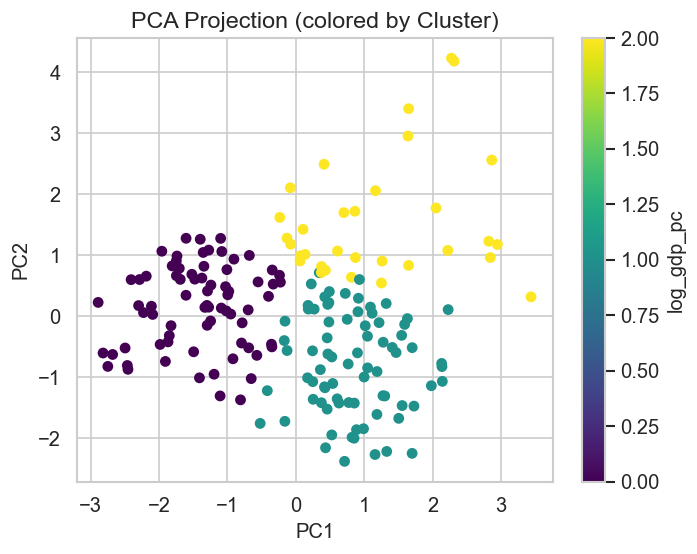

In [62]:
# extract main dimension (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# scatter them 
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_df["cluster"],
    cmap="viridis",
    s=30)
    
plt.colorbar(label="log_gdp_pc")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (colored by Cluster)")
plt.show()

### UMAP analysis 
The UMAP visualization reveals a clear tension between economic growth and environmental sustainability. There is a visible positive correlation between wealth and emissions, as the clusters with the highest GDP per capita also show the highest carbon footprints. In contrast, the green share and non-green share plots act as near-perfect inverses; the points with the most significant sustainable activity are currently clustered in the lower-wealth regions. Ultimately, the data highlights a significant sustainability gap: the top-right clusters represent high-income but high-polluting entities, while the bottom-left reflects a greener but less wealthy profile, suggesting that a high-GDP, high-green-share model has not yet become a dominant reality.

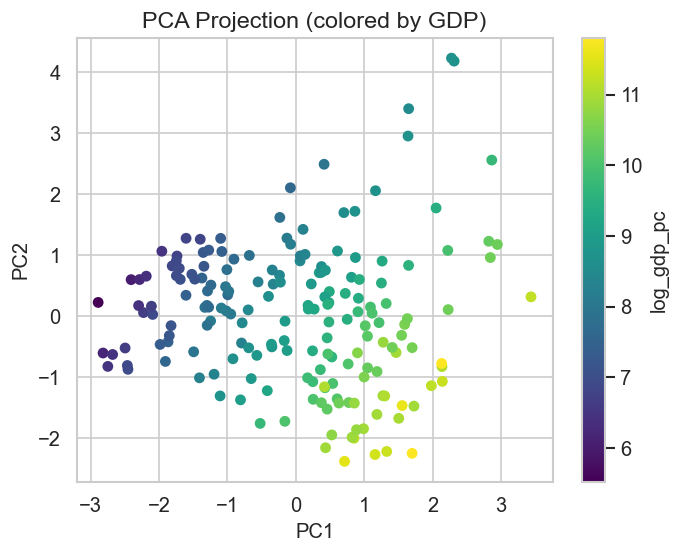

In [63]:
# extract main dimension
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_df["log_gdp_pc"],
    cmap="viridis",
    s=30
)
plt.colorbar(label="log_gdp_pc")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (colored by GDP)")
plt.show()

### Comparison to UMAP
Compared to the UMAP projection, which reveals a nonlinear manifold structure, the PCA projection appears more compressed and less structured. This highlights the limitation of PCA in capturing nonlinear relationships, as it can only represent linear combinations of features.

In [64]:
pca.components_

array([[ 0.62827449,  0.71392037,  0.198551  ,  0.23699444],
       [-0.4207478 , -0.01525406,  0.70498969,  0.57072597]])

### More than just GDP?

In order to fact-check the conclusion of my PCA plot I decided to look at the values indivudually. We can actually see that the model trained more than purely GDP. It detected two dimensions:<br>
-**Wealth**: Cluster one is deemed welthy and efficient <br>
-**Energy and emmision efficiency**: Developmental countries like cluster 0 are low-income and inefficient, whereas cluster two depict very carbon-intensive economies



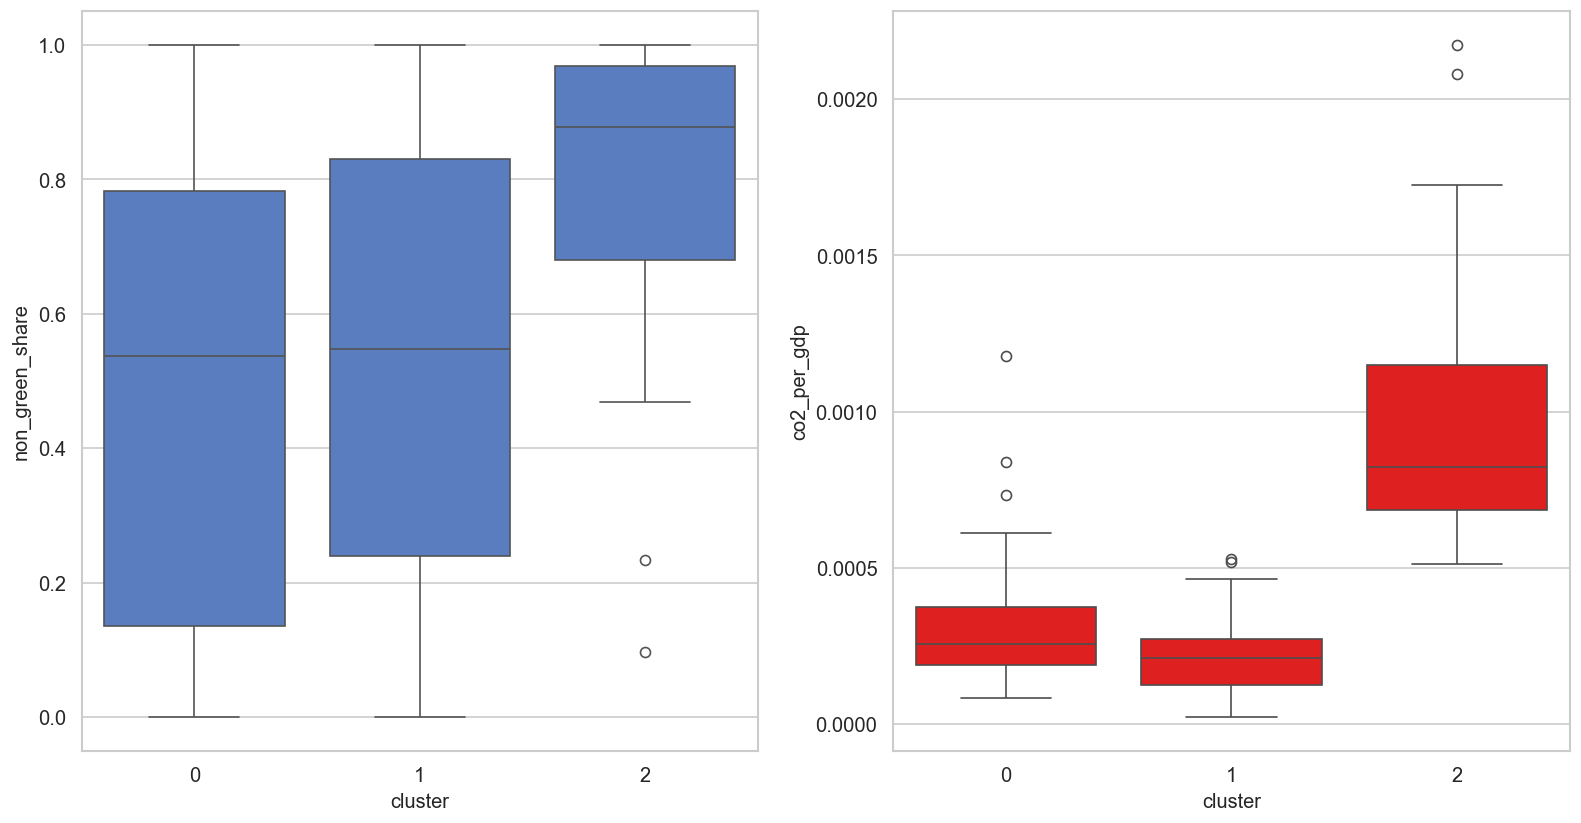

In [65]:
fig, (ax,ax2) = plt.subplots(1, 2,figsize=(16,8))

sns.boxplot(data=cluster_df, x="cluster", y="non_green_share", ax=ax)
sns.boxplot(data=cluster_df, x="cluster", y="co2_per_gdp", ax=ax2, color='red')
plt.show()

In [66]:
# look at countries in cluster 2
cluster_df[cluster_df["cluster"] == 2].sort_values("co2_per_gdp", ascending=False)

,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,...,solar,wind,hydro,nuclear,oil,gas,coal,green_share,non_green_share,cluster
3301,Mongolia,2023,MNG,3.431938e+06,44.184,2.032512e+10,12.874358,5922.345157,8.686657,2.630042,...,0.19,0.51,0.06,0.00,0.47,0.00,7.06,0.091677,0.908323,2
5160,Turkmenistan,2023,TKM,7.364437e+06,95.421,4.589454e+10,12.956999,6231.914085,8.737599,2.635981,...,0.00,0.00,0.01,0.00,0.00,32.59,0.00,0.000307,0.999693,2
2376,Iran,2023,IRN,9.060871e+07,789.676,4.575105e+11,8.715233,5049.299261,8.527203,2.273695,...,0.68,1.21,22.82,6.64,27.98,321.96,0.71,0.082116,0.917884,2
2756,Laos,2023,LAO,7.665001e+06,24.157,1.584316e+10,3.151598,2066.947640,7.634312,1.423493,...,0.08,0.00,40.00,0.00,0.00,0.00,12.18,0.767113,0.232887,2
2891,Libya,2023,LBY,7.305659e+06,64.219,4.402766e+10,8.790309,6026.515187,8.704090,2.281393,...,0.01,0.00,0.00,0.00,8.84,24.90,0.00,0.000296,0.999704,2
5070,Trinidad and Tobago,2023,TTO,1.502938e+06,35.536,2.503699e+10,23.644355,16658.700108,9.720748,3.204548,...,0.01,0.00,0.00,0.00,0.04,9.47,0.00,0.001050,0.998950,2
5393,Uzbekistan,2023,UZB,3.565231e+07,122.872,1.026419e+11,3.446397,2878.968470,7.965535,1.492094,...,0.45,0.55,6.60,0.00,1.50,62.00,5.70,0.098958,0.901042,2
5442,Venezuela,2023,VEN,2.830086e+07,119.588,1.023765e+11,4.225596,3617.435051,8.193797,1.653569,...,0.01,0.02,64.98,0.00,3.26,3.69,0.00,0.903419,0.096581,2
4637,South Africa,2023,ZAF,6.321239e+07,436.604,3.814407e+11,6.906938,6034.271899,8.705376,2.067741,...,14.81,11.60,2.00,8.10,3.68,0.00,192.29,0.158747,0.841253,2
2631,Kazakhstan,2023,KAZ,2.033011e+07,286.175,2.618401e+11,14.076412,12879.424358,9.463464,2.713131,...,1.87,3.78,8.80,0.00,0.63,33.25,65.25,0.127300,0.872700,2


You could have a look at the least efficient economies from earlier: They're pretty much the same. The model actually found a useful economical structure without being given earlier information.

Let's have a look at the efficiency of cluster 2 in comparison to cluster 0 and 1

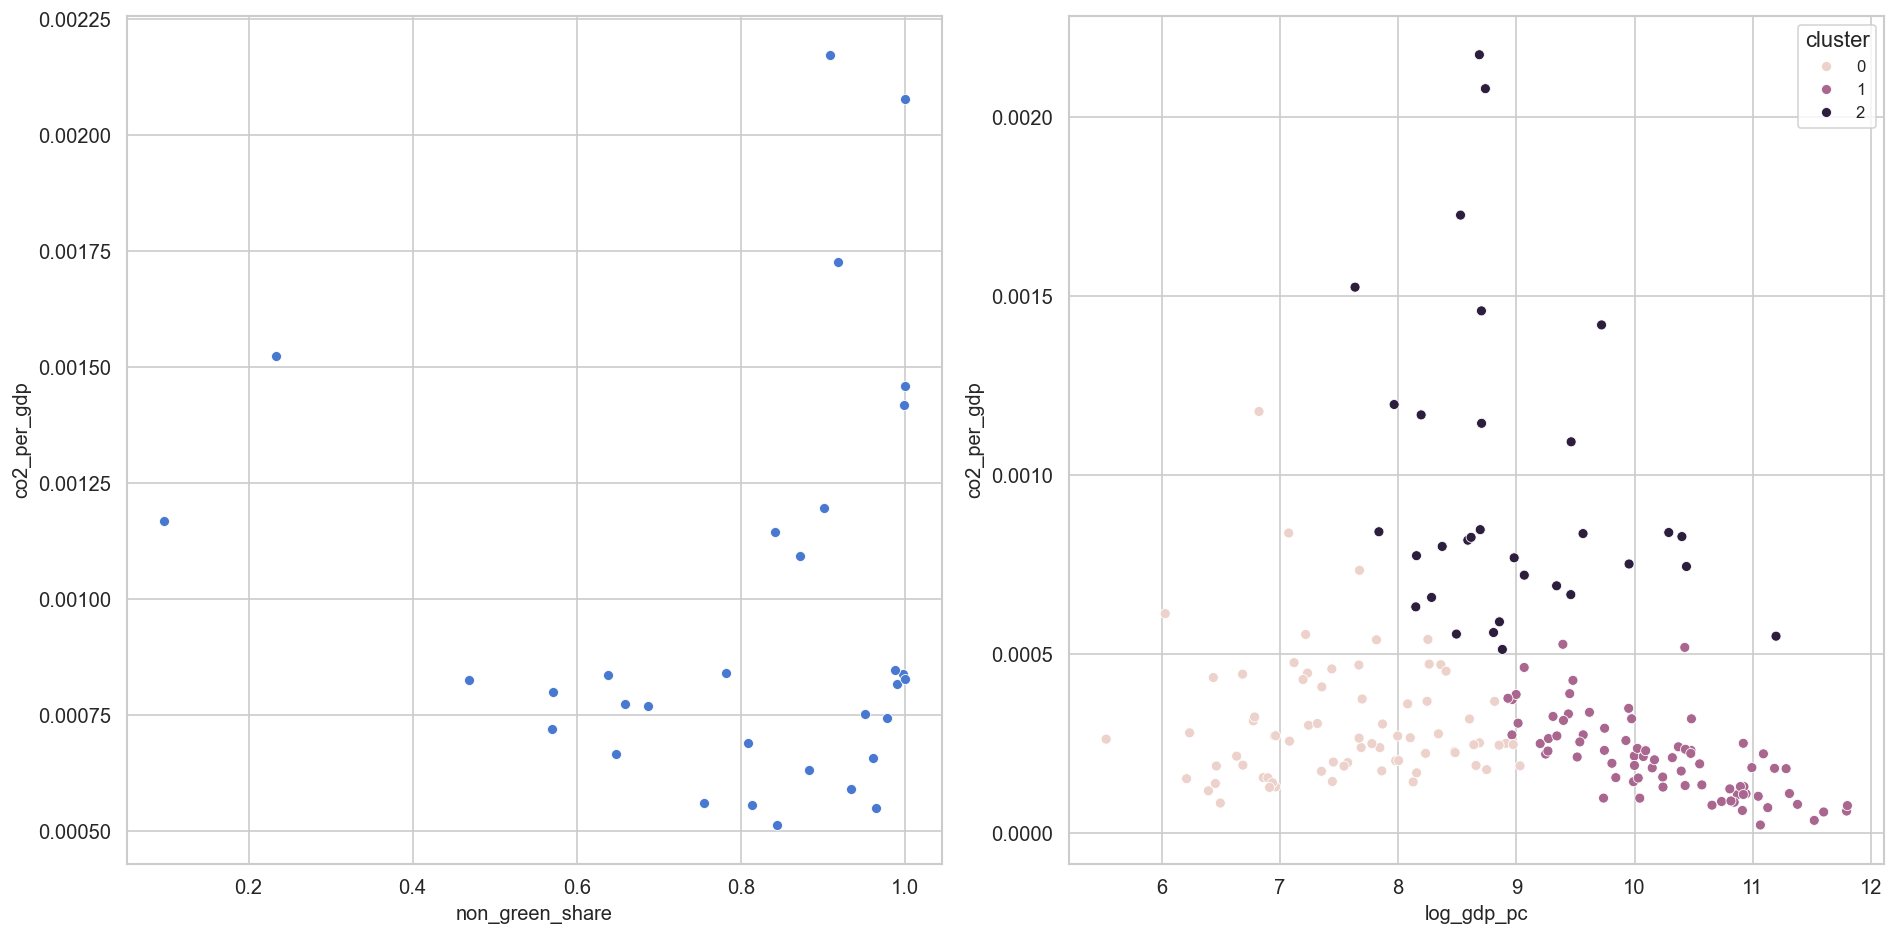

In [67]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(16,8))

# only look at cluster 2
cluster2 = cluster_df[cluster_df["cluster"] == 2]

# scatter
sns.scatterplot(
    data=cluster2,
    x="non_green_share",
    y="co2_per_gdp",
    ax=ax1)

sns.scatterplot(
    data=cluster_df,
    x="log_gdp_pc",
    y="co2_per_gdp",
    hue="cluster",
    ax=ax2
)

plt.tight_layout()
plt.show()

This reaffirms the suspicions, that cluster two is a real economic phenomenon with low-efficiency economies, mostly being run on fossil fuels. Some countries in cluster two like Laos or Vietnam might not have a high non_green share, however this might be explainable by their post-communist/communist, low-efficient economies.

Therefore we can say, that the Carbon intensity of economy is not mainly determined by economies. Structural differences like the energy-mix, industry-profile also play a significant role.


### What are the consequences?

A major driving factor for the climate change are said low-income, high-intensity economies we've looked at. Economies that see a high correlation between carbon emmisions and economic growth with little to no decoupling. 

I'm sure we are all aware of the consequences but let's also have a look at the global climate.

In [68]:
# get the data from the internet
url = "https://nyc3.digitaloceanspaces.com/owid-public/data/co2/owid-co2-data.json"
# request the richer JSON endpoint, not the smaller csv
response = requests.get(url, timeout=30)
response.raise_for_status()

# parse the body to a normal python dictionary
response = response.json()

len(response)

255

In [69]:
# flatten the nested country -> yearly-record JSON structure
json_df = flatten_owid_panel_json(response, min_year=1970)

# choose the source columns we want to track later
driver_cols = [
    "coal_co2",
    "oil_co2",
    "gas_co2",
    "cement_co2",
    "flaring_co2",
    "other_industry_co2",
]

# quick coverage check: which JSON metrics are usually populated?
coverage_df = (
    json_df[driver_cols + ["co2"]]
    .notna()
    .mean()
    .sort_values(ascending=False)
    .rename_axis("metric")
    .reset_index(name="non_null_share")
)

coverage_df

,metric,non_null_share
0,co2,0.946739
1,oil_co2,0.895739
2,cement_co2,0.875456
3,flaring_co2,0.687582
4,coal_co2,0.626806
5,gas_co2,0.522253
6,other_industry_co2,0.168831


In [70]:
# keep only countries that belong to cluster 2
cluster_2_json = json_df[json_df["iso_code"].isin(cluster2["iso_code"])].copy()

# sort for easier reading and safer time-series work
cluster_2_json = cluster_2_json.sort_values(["country", "year"]).reset_index(drop=True)

cluster_2_json[["country", "year", "co2", "consumption_co2", "coal_co2", "oil_co2"]].head()

,country,year,co2,consumption_co2,coal_co2,oil_co2
0,Algeria,1970,15.058960,NaN,0.970960,6.837024
1,Algeria,1971,18.649530,NaN,0.901344,7.617456
2,Algeria,1972,28.322639,NaN,0.648528,7.258384
3,Algeria,1973,38.277401,NaN,0.820736,9.376176
4,Algeria,1974,31.876659,NaN,0.699824,9.607008


In [71]:
# aggregate all numeric cluster values per year
cluster_2_per_year = cluster_2_json.groupby("year").sum(numeric_only=True).reset_index()

# keep the global totals so we can build proper world shares
world_df = (
    json_df[json_df["country"] == "World"][["year", "co2", "population"]]
    .rename(columns={"co2": "world_co2", "population": "world_population"})
)

# merge cluster and world totals on year
cluster_2_per_year = cluster_2_per_year.merge(world_df, on="year", how="left")

# rebuild per-capita values from absolute totals instead of summing country ratios
cluster_2_per_year["cement_co2_per_capita_cluster"] = safe_divide(
    cluster_2_per_year["cement_co2"] * 1_000_000,
    cluster_2_per_year["population"],
)

# compare the cluster against the world in a fair way
cluster_2_per_year["cluster_share_of_world_co2"] = safe_divide(
    cluster_2_per_year["co2"],
    cluster_2_per_year["world_co2"],
)
cluster_2_per_year["cluster_share_of_world_population"] = safe_divide(
    cluster_2_per_year["population"],
    cluster_2_per_year["world_population"],
)

cluster_2_per_year[[
    "year",
    "co2",
    "population",
    "cement_co2_per_capita_cluster",
    "cluster_share_of_world_co2",
    "cluster_share_of_world_population",
]].tail()

,year,co2,population,cement_co2_per_capita_cluster,cluster_share_of_world_co2,cluster_share_of_world_population
49,2019,19664.884130,3.935808e+09,0.307497,0.529990,0.503861
50,2020,19350.567779,3.961400e+09,0.308506,0.550882,0.502269
51,2021,20291.268908,3.982164e+09,0.314675,0.548535,0.500621
52,2022,20609.810649,4.002440e+09,0.292292,0.552633,0.498970
53,2023,21478.522725,4.023580e+09,0.284822,0.568342,0.497246


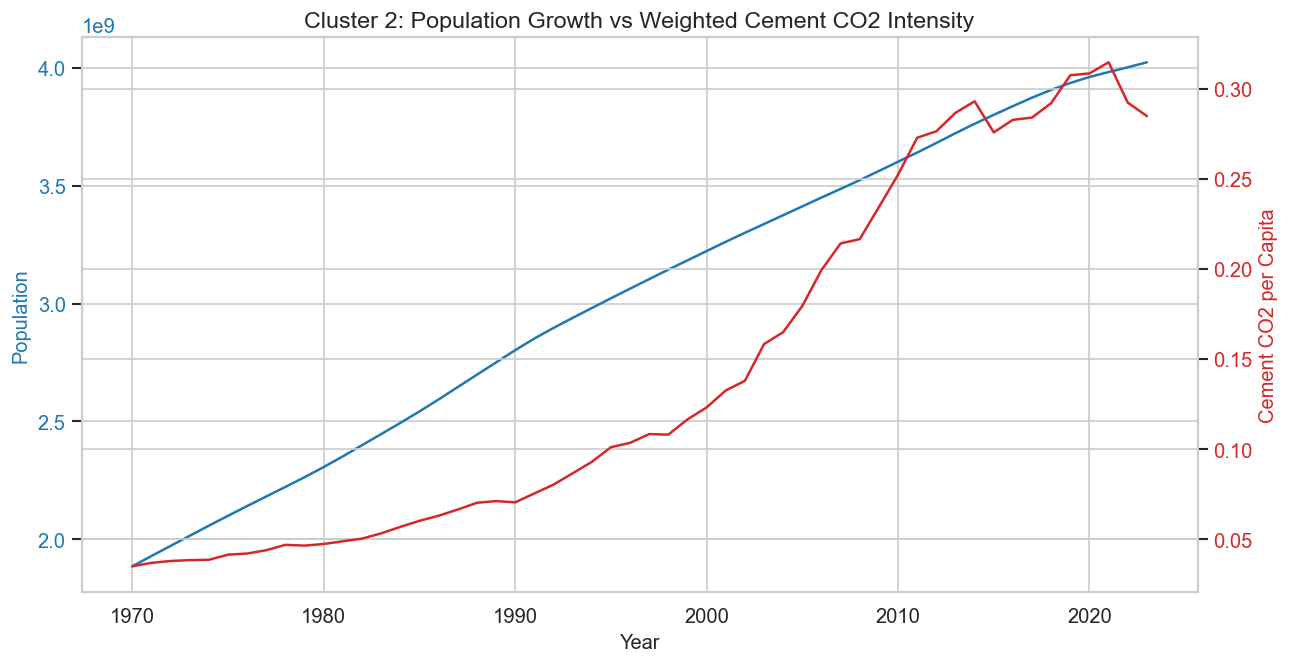

In [72]:
# compare cluster size with weighted cement intensity
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel("Year")
ax1.set_ylabel("Population", color="tab:blue")
ax1.plot(cluster_2_per_year["year"], cluster_2_per_year["population"], color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# the second axis keeps the intensity trend readable
ax2 = ax1.twinx()
ax2.set_ylabel("Cement CO2 per Capita", color="tab:red")
ax2.plot(
    cluster_2_per_year["year"],
    cluster_2_per_year["cement_co2_per_capita_cluster"],
    color="tab:red",
)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Cluster 2: Population Growth vs Weighted Cement CO2 Intensity")
plt.show()

The earlier version simply summed country-level per-capita values, which can distort the story. Rebuilding the cluster-level per-capita series from absolute cement emissions and total population is a stronger example of technical data handling and gives a more defensible trend line.

### Feature 1: Emissions-Source Decomposition from the JSON Panel

The OWID JSON contains a richer breakdown than the smaller CSV we used earlier. We can reshape the source columns into a long table, aggregate them year by year for Cluster 2, and inspect how the composition of emissions changes over time.

In [73]:
# melt the wide source columns into a tidy long table
cluster_2_source_trend = prepare_source_trend_table(
    cluster_2_json,
    source_cols=driver_cols,
    time_col="year",
    total_col="co2",
)

# smooth the shares so the structural trend is easier to read
cluster_2_source_trend["source_share_5y"] = (
    cluster_2_source_trend
    .sort_values(["source_label", "year"])
    .groupby("source_label")["source_share"]
    .transform(lambda values: values.rolling(5, min_periods=1).mean())
)

# pivot back to wide format for the stacked area chart
source_mix_pivot = (
    cluster_2_source_trend
    .pivot(index="year", columns="source_label", values="source_share_5y")
    .fillna(0)
)

source_mix_pivot.tail()

source_label,Coal,Oil,Gas,Cement,Flaring,Other Industry
year,,,,,,
2019,0.564671,0.206333,0.154252,0.060116,0.010633,0.015801
2020,0.563275,0.204001,0.156932,0.060998,0.010632,0.015612
2021,0.564589,0.199906,0.159536,0.061238,0.010600,0.015282
2022,0.567528,0.195735,0.161422,0.060637,0.010517,0.014991
2023,0.571143,0.192845,0.162161,0.059315,0.010413,0.014640


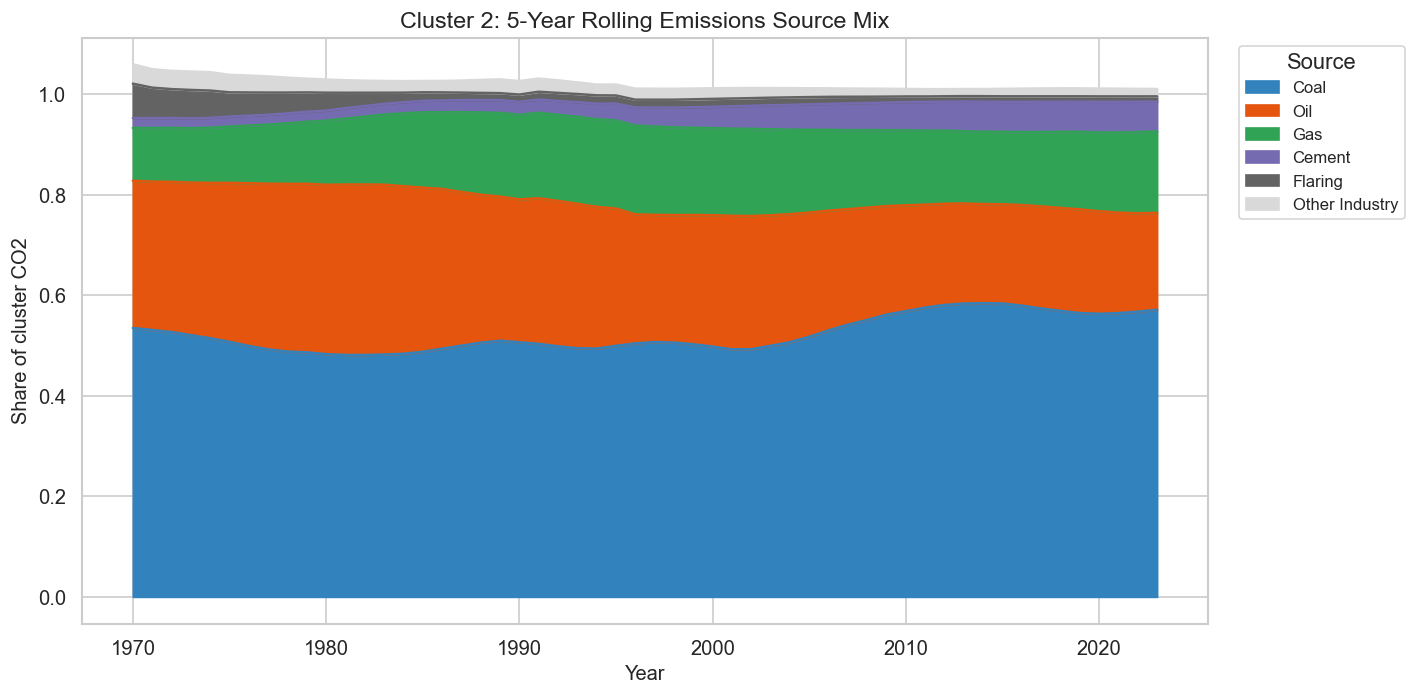

In [74]:
# visualize how the internal source mix changes over time
ax = source_mix_pivot.plot.area(figsize=(12, 6), cmap="tab20c")
ax.set_title("Cluster 2: 5-Year Rolling Emissions Source Mix")
ax.set_xlabel("Year")
ax.set_ylabel("Share of cluster CO2")

# move the legend outside so it does not cover the area chart
ax.legend(title="Source", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

This adds a more sophisticated JSON transformation to the notebook: wide source fields are melted into a tidy long table, aggregated, and then smoothed with a rolling window. It shows not just how much Cluster 2 emits, but how the internal source structure shifts over time.

### Feature 2: Concentration and Global Share Dynamics

Another useful question is whether Cluster 2's emissions burden is broad-based or dominated by a few very large countries. We can measure that with concentration metrics and compare the cluster's share of world CO2 against its share of world population.

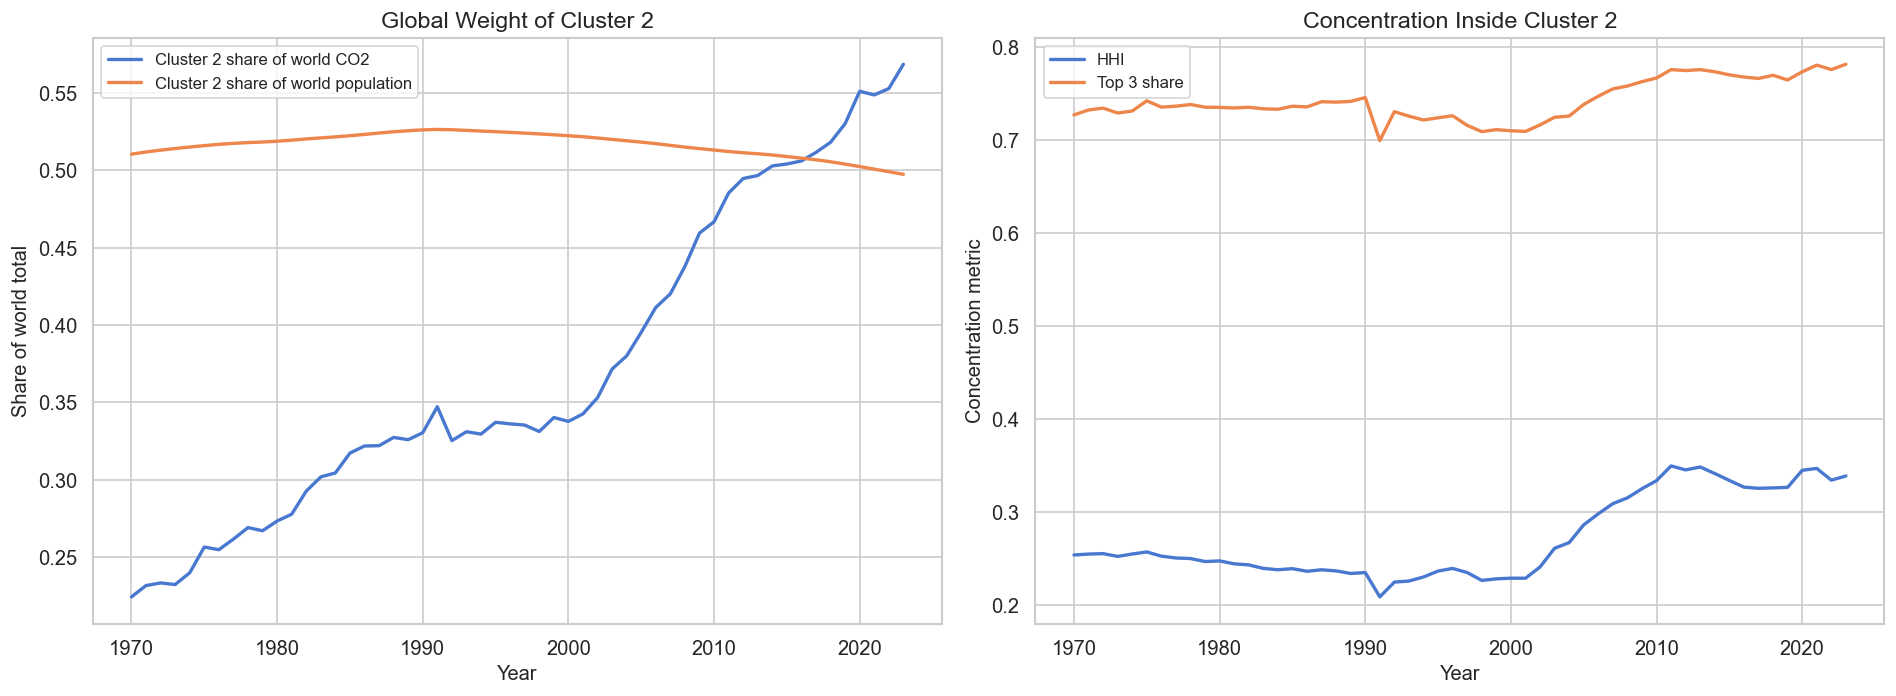

,country,co2
377,China,11902.502930
539,India,3062.324463
1241,Russia,1815.924683
647,Iran,817.879883
593,Indonesia,733.223938
1295,South Africa,401.893097
1727,Vietnam,334.726074
1025,Malaysia,288.823669
431,Egypt,269.006195
1403,Thailand,264.388641


In [75]:
# measure how dominant the biggest countries are inside the cluster
cluster_2_concentration = compute_group_concentration(
    cluster_2_json,
    period_col="year",
    entity_col="country",
    value_col="co2",
    top_n=3,
)

# latest snapshot for a quick ranking table
latest_year = int(cluster_2_json["year"].max())
latest_cluster_emitters = (
    cluster_2_json[cluster_2_json["year"] == latest_year][["country", "co2"]]
    .dropna()
    .sort_values("co2", ascending=False)
    .head(10)
)

# compare global weight and internal concentration side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(
    cluster_2_per_year["year"],
    cluster_2_per_year["cluster_share_of_world_co2"],
    label="Cluster 2 share of world CO2",
    linewidth=2,
)
ax1.plot(
    cluster_2_per_year["year"],
    cluster_2_per_year["cluster_share_of_world_population"],
    label="Cluster 2 share of world population",
    linewidth=2,
)
ax1.set_title("Global Weight of Cluster 2")
ax1.set_xlabel("Year")
ax1.set_ylabel("Share of world total")
ax1.legend()

# HHI and top-3 share show whether a few countries dominate the cluster
ax2.plot(cluster_2_concentration["year"], cluster_2_concentration["hhi"], label="HHI", linewidth=2)
ax2.plot(cluster_2_concentration["year"], cluster_2_concentration["top_n_share"], label="Top 3 share", linewidth=2)
ax2.set_title("Concentration Inside Cluster 2")
ax2.set_xlabel("Year")
ax2.set_ylabel("Concentration metric")
ax2.legend()

plt.tight_layout()
plt.show()

latest_cluster_emitters

This final section turns the JSON panel into two extra analytical layers: world-normalized shares and within-cluster concentration. Together they help answer whether the cluster matters because many member economies are carbon-intensive, or because a handful of giant emitters pull the group upward.